**H-NMR Classification with Random Forest**

========================================

This notebook focuses on Random Forest classification of H-NMR spectra,
including hyperparameter tuning and model interpretation.

**Random Forest Hyperparameter Tuning**

After CNNs failed to learn meaningful patterns from the binned H-NMR spectra, we focused on optimizing Random Forest as the primary classification method.

**Approach**

- Baseline model: Random Forest with 200 trees, max_depth=20
- Grid Search: Systematic hyperparameter optimization using 5-fold cross-validation across 648 parameter combinations
- Parameters tuned: n_estimators (100-500), max_depth (10-30/None), min_samples_split (2-10), min_samples_leaf (1-4), max_features (sqrt/log2/None)

**Results**
- Improvement: +1.56% test accuracy

**Best Hyperparameters**

- n_estimators: 200
- max_depth: 25 (slightly deeper than baseline)
- max_features: 'log2' (more restrictive feature selection)
- min_samples_split: 2, min_samples_leaf: 1 (standard values)
- Best CV score: 69.3%

**Key Observations**

- Lipids are most distinctive with 86% recall, suggesting clear spectral signatures
- Heterocycles struggle with only 33% recall, frequently confused with other classes (especially Nitrogenous acids)
- 66.4% appears near optimal given the inherent class overlap observed in PCA analysis
- The modest improvement from tuning suggests the baseline was already reasonably configured

H-NMR CLASSIFICATION WITH RANDOM FOREST

[1] Loading preprocessed data...
Data shape: (847, 400)
Number of samples: 847
Number of features (bins): 400
Classes: ['Aromatics' 'Heterocycles & nucleotides' 'Lipids'
 'Nitrogenous & organic acids' 'Organic oxygen compounds']

Class distribution:
  Aromatics............................... 127 ( 15.0%)
  Heterocycles & nucleotides.............. 180 ( 21.3%)
  Lipids.................................. 189 ( 22.3%)
  Nitrogenous & organic acids............. 251 ( 29.6%)
  Organic oxygen compounds................ 100 ( 11.8%)

[2] Encoding labels...
Number of classes: 5
Class encoding: {'Aromatics': 0, 'Heterocycles & nucleotides': 1, 'Lipids': 2, 'Nitrogenous & organic acids': 3, 'Organic oxygen compounds': 4}

[3] Creating stratified train/val/test splits...
Train set: 592 samples (69.9%)
Val set:   127 samples (15.0%)
Test set:  128 samples (15.1%)

Class distribution in splits:
Train: {np.int64(0): np.int64(89), np.int64(1): np.int64(126), np.

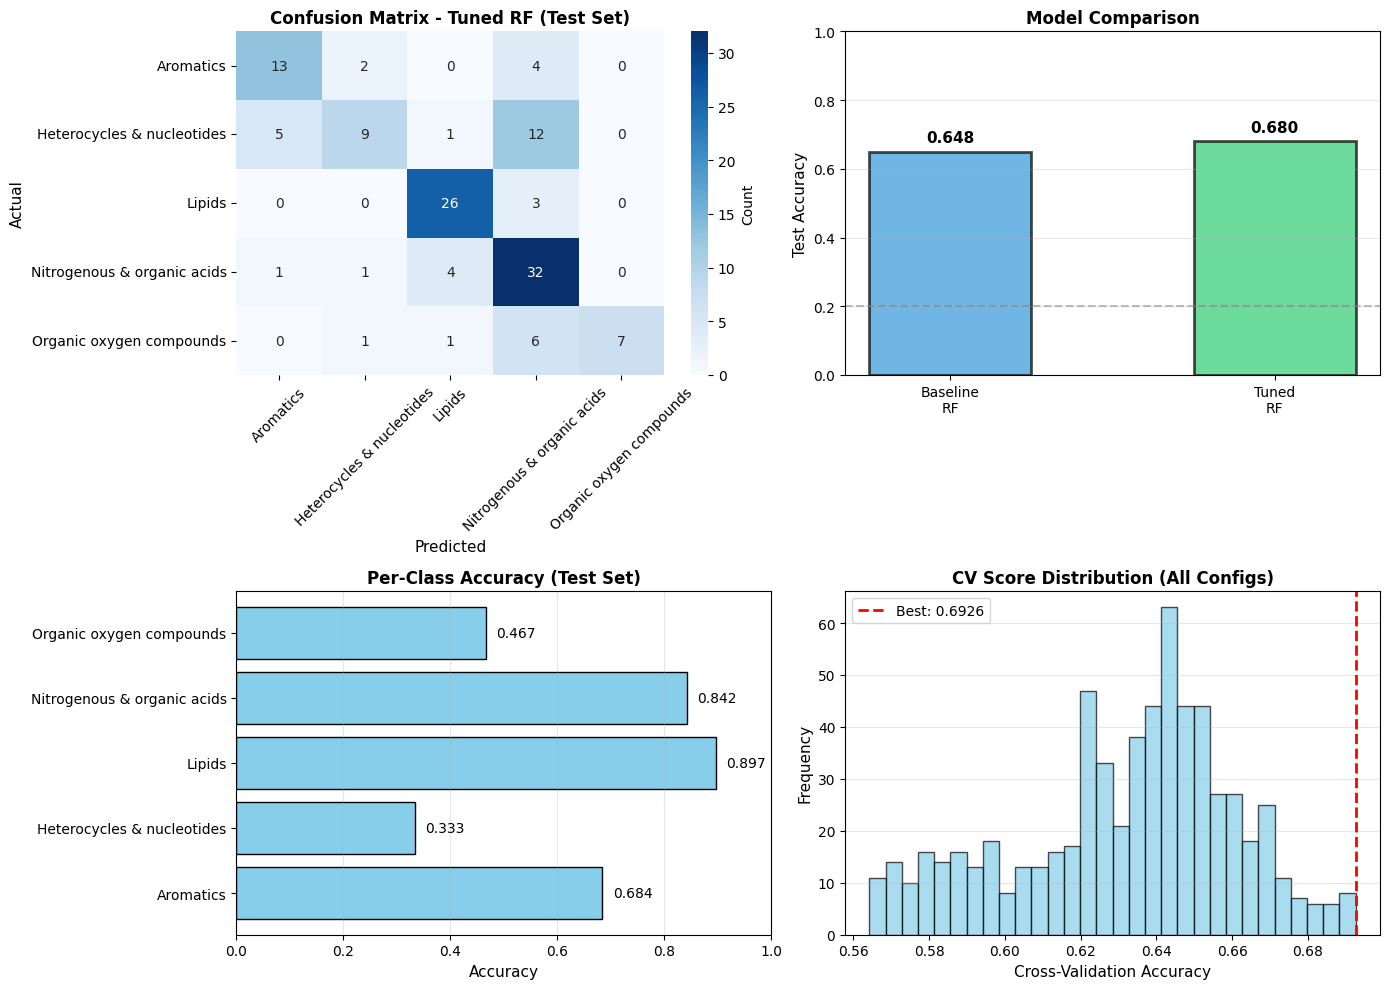


SUMMARY
Baseline RF test accuracy:  0.6484
Tuned RF test accuracy:     0.6797
Improvement:                +3.12%

Best hyperparameters: {'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, confusion_matrix, classification_report)

# Set random seed for reproducibility
np.random.seed(42)

print("="*60)
print("H-NMR CLASSIFICATION WITH RANDOM FOREST")
print("="*60)

# --- 1. LOAD PREPROCESSED DATA ---
print("\n[1] Loading preprocessed data...")
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

# Separate features and labels
X = df.iloc[:, 2:].values  # All bin columns (skip accession and group)
y = df['group'].values
accessions = df['accession'].values

print(f"Data shape: {X.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of features (bins): {X.shape[1]}")
print(f"Classes: {np.unique(y)}")

# Class distribution
print(f"\nClass distribution:")
for group in np.unique(y):
    count = (y == group).sum()
    pct = 100 * count / len(y)
    print(f"  {group:.<40} {count:>3} ({pct:>5.1f}%)")

# --- 2. ENCODE LABELS ---
print("\n[2] Encoding labels...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

print(f"Number of classes: {n_classes}")
print(f"Class encoding: {dict(zip(le.classes_, range(n_classes)))}")

# --- 3. TRAIN/VAL/TEST SPLIT ---
print("\n[3] Creating stratified train/val/test splits...")

# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp, acc_train, acc_temp = train_test_split(
    X, y_encoded, accessions, test_size=0.30, random_state=42, stratify=y_encoded
)

# Second split: split temp into 50/50 (15% val, 15% test)
X_val, X_test, y_val, y_test, acc_val, acc_test = train_test_split(
    X_temp, y_temp, acc_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"Val set:   {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

# Verify stratification
print("\nClass distribution in splits:")
for split_name, split_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    print(f"{split_name}: {dict(zip(unique, counts))}")

# --- 4. BASELINE RANDOM FOREST ---
print("\n" + "="*60)
print("[4] BASELINE RANDOM FOREST")
print("="*60)

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

# Evaluate baseline
train_acc_baseline = rf_baseline.score(X_train, y_train)
val_acc_baseline = rf_baseline.score(X_val, y_val)
test_acc_baseline = rf_baseline.score(X_test, y_test)

print(f"\nBaseline RF Accuracy:")
print(f"  Train: {train_acc_baseline:.4f}")
print(f"  Val:   {val_acc_baseline:.4f}")
print(f"  Test:  {test_acc_baseline:.4f}")

# --- 5. HYPERPARAMETER TUNING ---
print("\n" + "="*60)
print("[5] HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print(f"\nParameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")
print("Running GridSearchCV (this may take a few minutes)...")

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)

print(f"\n✓ Grid search complete!")
print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")

# --- 6. EVALUATE TUNED MODEL ---
print("\n" + "="*60)
print("[6] EVALUATING TUNED MODEL")
print("="*60)

rf_tuned = grid_search.best_estimator_

# Predictions
y_train_pred = rf_tuned.predict(X_train)
y_val_pred = rf_tuned.predict(X_val)
y_test_pred = rf_tuned.predict(X_test)

# Calculate metrics
train_acc_tuned = accuracy_score(y_train, y_train_pred)
val_acc_tuned = accuracy_score(y_val, y_val_pred)
test_acc_tuned = accuracy_score(y_test, y_test_pred)

train_f1_tuned = f1_score(y_train, y_train_pred, average='weighted')
val_f1_tuned = f1_score(y_val, y_val_pred, average='weighted')
test_f1_tuned = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nTuned RF Accuracy:")
print(f"  Train: {train_acc_tuned:.4f}")
print(f"  Val:   {val_acc_tuned:.4f}")
print(f"  Test:  {test_acc_tuned:.4f}")

print(f"\nTuned RF F1-Score (weighted):")
print(f"  Train: {train_f1_tuned:.4f}")
print(f"  Val:   {val_f1_tuned:.4f}")
print(f"  Test:  {test_f1_tuned:.4f}")

print(f"\nImprovement over baseline:")
print(f"  Test accuracy: {test_acc_baseline:.4f} → {test_acc_tuned:.4f} ({100*(test_acc_tuned - test_acc_baseline):+.2f}%)")

# Classification report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# --- 7. VISUALIZATION ---
print("\n[7] Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, 
            ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_xlabel('Predicted', fontsize=11)
axes[0, 0].set_ylabel('Actual', fontsize=11)
axes[0, 0].set_title('Confusion Matrix - Tuned RF (Test Set)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Model comparison
models = ['Baseline\nRF', 'Tuned\nRF']
test_accuracies = [test_acc_baseline, test_acc_tuned]
colors = ['#3498db', '#2ecc71']
bars = axes[0, 1].bar(models, test_accuracies, color=colors, alpha=0.7,
                      edgecolor='black', linewidth=2, width=0.5)
axes[0, 1].set_ylabel('Test Accuracy', fontsize=11)
axes[0, 1].set_title('Model Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Random (20%)')

for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{acc:.3f}', ha='center', va='bottom', 
                    fontsize=11, fontweight='bold')

# Per-class accuracy
class_accuracies = []
for i, class_name in enumerate(le.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = (y_test_pred[mask] == i).sum() / mask.sum()
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

axes[1, 0].barh(range(len(le.classes_)), class_accuracies, color='skyblue',
                edgecolor='black', linewidth=1)
axes[1, 0].set_yticks(range(len(le.classes_)))
axes[1, 0].set_yticklabels(le.classes_, fontsize=10)
axes[1, 0].set_xlabel('Accuracy', fontsize=11)
axes[1, 0].set_title('Per-Class Accuracy (Test Set)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='x')

for i, acc in enumerate(class_accuracies):
    axes[1, 0].text(acc + 0.02, i, f'{acc:.3f}', va='center', fontsize=10)

# Cross-validation scores distribution
cv_results = pd.DataFrame(grid_search.cv_results_)
top_10_indices = cv_results['rank_test_score'] <= 10
top_10_scores = cv_results.loc[top_10_indices, 'mean_test_score'].values

axes[1, 1].hist(cv_results['mean_test_score'], bins=30, color='skyblue',
                edgecolor='black', alpha=0.7)
axes[1, 1].axvline(grid_search.best_score_, color='red', linestyle='--',
                   linewidth=2, label=f'Best: {grid_search.best_score_:.4f}')
axes[1, 1].set_xlabel('Cross-Validation Accuracy', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('CV Score Distribution (All Configs)', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('RF_classifier_figures/rf_tuned_results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rf_tuned_results.png")
plt.show()

# --- 8. SUMMARY ---
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Baseline RF test accuracy:  {test_acc_baseline:.4f}")
print(f"Tuned RF test accuracy:     {test_acc_tuned:.4f}")
print(f"Improvement:                {100*(test_acc_tuned - test_acc_baseline):+.2f}%")
print(f"\nBest hyperparameters: {grid_search.best_params_}")
print("="*60)

**Save model**

This script:
1. Saves the trained Random Forest model
2. Saves preprocessing parameters (normalization stats)

In [7]:
"""
Model Saving
============
Save the trained Random Forest model and preprocessing parameters for deployment.
"""

import pickle
import json
import numpy as np
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Recalculate normalization parameters from training data
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

# --- 1. SAVE THE TRAINED MODEL ---
print("="*60)
print("SAVING TRAINED MODEL")
print("="*60)

# Save the model using pickle
model_filename = 'models/rf_tuned_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(rf_tuned, f)
print(f"✓ Saved model to: {model_filename}")

# Save the label encoder
encoder_filename = 'models/label_encoder.pkl'
with open(encoder_filename, 'wb') as f:
    pickle.dump(le, f)
print(f"✓ Saved label encoder to: {encoder_filename}")

# --- 2. SAVE PREPROCESSING PARAMETERS ---
preprocessing_params = {
    'ppm_min': 0.0,
    'ppm_max': 10.0,
    'n_bins': 400,
    'normalization_mean': mean.tolist(),
    'normalization_std': std.tolist(),
    'bin_edges': np.linspace(0.0, 10.0, 401).tolist()
}

params_filename = 'models/preprocessing_params.json'
with open(params_filename, 'w') as f:
    json.dump(preprocessing_params, f, indent=2)
print(f"✓ Saved preprocessing parameters to: {params_filename}")

print("\nFiles saved successfully!")
print("These files are needed for deployment:")
print(f"  1. {model_filename} - Trained Random Forest model")
print(f"  2. {encoder_filename} - Label encoder for class names")
print(f"  3. {params_filename} - Preprocessing parameters")
print("="*60)

SAVING TRAINED MODEL
✓ Saved model to: models/rf_tuned_model.pkl
✓ Saved label encoder to: models/label_encoder.pkl
✓ Saved preprocessing parameters to: models/preprocessing_params.json

Files saved successfully!
These files are needed for deployment:
  1. models/rf_tuned_model.pkl - Trained Random Forest model
  2. models/label_encoder.pkl - Label encoder for class names
  3. models/preprocessing_params.json - Preprocessing parameters


**Feature importance analysis**

Produces a figure showing which ppm regions are important for classification

Loading model and parameters...
✓ Model loaded

Feature importance statistics:
  Mean importance: 0.002500
  Max importance: 0.017036
  Top 10 bins account for: 14.52% of total

Top 20 most important ppm regions:
  3.634 ppm: 0.017036
  1.504 ppm: 0.015309
  1.604 ppm: 0.015216
  1.278 ppm: 0.015172
  3.659 ppm: 0.015100
  1.303 ppm: 0.014122
  1.554 ppm: 0.013645
  0.852 ppm: 0.013398
  1.253 ppm: 0.013279
  1.629 ppm: 0.012913
  1.328 ppm: 0.012860
  1.529 ppm: 0.012777
  0.902 ppm: 0.012185
  3.810 ppm: 0.011403
  3.734 ppm: 0.011338
  3.709 ppm: 0.010929
  0.877 ppm: 0.010616
  3.784 ppm: 0.010599
  6.867 ppm: 0.010383
  7.318 ppm: 0.010006


c:\Users\nilsa\GitHub\DDLS_project\code\venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\nilsa\GitHub\DDLS_project\code\venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



✓ Saved: RF_classifier_figures/feature_importance_nmr_style.png


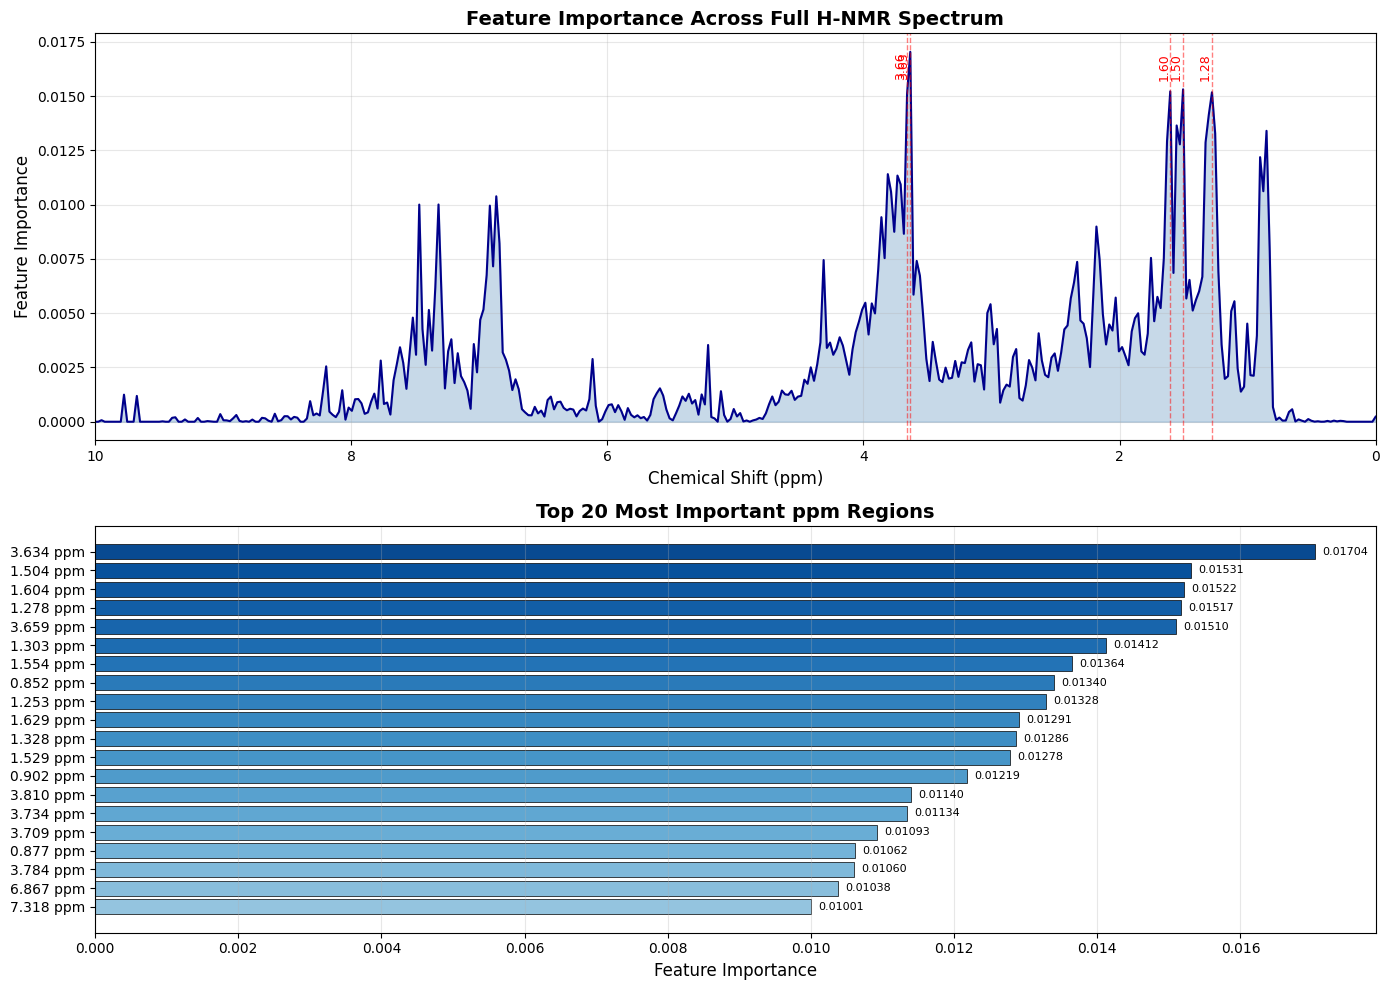


CHEMICAL SHIFT REGION ANALYSIS

Importance by chemical shift region:

Aliphatic CH3/CH2 (0.5-2.0 ppm)
  Total importance: 0.321715 (32.2%)
  Average per bin: 0.005362
  Number of bins: 60

Alpha to heteroatom (2.0-4.5 ppm)
  Total importance: 0.432083 (43.2%)
  Average per bin: 0.004321
  Number of bins: 100

Olefinic/Anomeric (4.5-6.0 ppm)
  Total importance: 0.039267 (3.9%)
  Average per bin: 0.000654
  Number of bins: 60

Aromatic (6.0-8.5 ppm)
  Total importance: 0.201029 (20.1%)
  Average per bin: 0.002010
  Number of bins: 100

Aldehyde/Carboxylic (8.5-10.0 ppm)
  Total importance: 0.005467 (0.5%)
  Average per bin: 0.000093
  Number of bins: 59

✓ Saved: processed_data/feature_importance_data.csv

INTERPRETATION GUIDE

High importance regions indicate chemical shift ranges that are most
discriminative for compound classification. These peaks likely correspond to:

- Functional groups characteristic of specific compound classes
- Structural features unique to certain metabolite 

In [8]:
"""
Feature Importance Visualization
=================================
Extract and visualize which ppm regions are most important for classification.
Display as an NMR-style spectrum.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json
from pathlib import Path

# --- LOAD MODEL AND PARAMETERS ---
print("Loading model and parameters...")

MODEL_DIR = Path("models")
with open(MODEL_DIR / "rf_tuned_model.pkl", 'rb') as f:
    rf_model = pickle.load(f)

with open(MODEL_DIR / "preprocessing_params.json", 'r') as f:
    params = json.load(f)

print("✓ Model loaded")

# --- EXTRACT FEATURE IMPORTANCES ---
feature_importances = rf_model.feature_importances_

# Map bin indices to ppm values (center of each bin)
ppm_min = params['ppm_min']
ppm_max = params['ppm_max']
n_bins = params['n_bins']
bin_centers = np.linspace(ppm_min, ppm_max, n_bins)

# Create dataframe for analysis
importance_df = pd.DataFrame({
    'bin_index': range(n_bins),
    'ppm': bin_centers,
    'importance': feature_importances
})

print(f"\nFeature importance statistics:")
print(f"  Mean importance: {feature_importances.mean():.6f}")
print(f"  Max importance: {feature_importances.max():.6f}")
print(f"  Top 10 bins account for: {importance_df.nlargest(10, 'importance')['importance'].sum():.2%} of total")

# Find top important regions
top_n = 20
top_features = importance_df.nlargest(top_n, 'importance')
print(f"\nTop {top_n} most important ppm regions:")
for idx, row in top_features.iterrows():
    print(f"  {row['ppm']:.3f} ppm: {row['importance']:.6f}")

# --- VISUALIZATION ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Full spectrum view (NMR-style, inverted x-axis)
ax1 = axes[0]
ax1.fill_between(bin_centers, 0, feature_importances, alpha=0.3, color='steelblue')
ax1.plot(bin_centers, feature_importances, color='darkblue', linewidth=1.5)
ax1.set_xlim(ppm_max, ppm_min)  # Inverted for NMR convention
ax1.set_xlabel('Chemical Shift (ppm)', fontsize=12)
ax1.set_ylabel('Feature Importance', fontsize=12)
ax1.set_title('Feature Importance Across Full H-NMR Spectrum', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Highlight top regions
for _, row in top_features.head(5).iterrows():
    ax1.axvline(row['ppm'], color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax1.text(row['ppm'], ax1.get_ylim()[1] * 0.95, f"{row['ppm']:.2f}", 
             rotation=90, va='top', ha='right', fontsize=9, color='red')

# 2. Top 20 most important bins
ax2 = axes[1]
top_20 = importance_df.nlargest(20, 'importance').sort_values('importance', ascending=True)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_20)))

bars = ax2.barh(range(len(top_20)), top_20['importance'], color=colors, edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(top_20)))
ax2.set_yticklabels([f"{ppm:.3f} ppm" for ppm in top_20['ppm']], fontsize=10)
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('Top 20 Most Important ppm Regions', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, top_20['importance'])):
    ax2.text(val + 0.0001, i, f'{val:.5f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('RF_classifier_figures/feature_importance_nmr_style.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: RF_classifier_figures/feature_importance_nmr_style.png")
plt.show()

# --- REGION ANALYSIS ---
print("\n" + "="*60)
print("CHEMICAL SHIFT REGION ANALYSIS")
print("="*60)

# Define typical NMR regions
regions = {
    'Aliphatic CH3/CH2 (0.5-2.0 ppm)': (0.5, 2.0),
    'Alpha to heteroatom (2.0-4.5 ppm)': (2.0, 4.5),
    'Olefinic/Anomeric (4.5-6.0 ppm)': (4.5, 6.0),
    'Aromatic (6.0-8.5 ppm)': (6.0, 8.5),
    'Aldehyde/Carboxylic (8.5-10.0 ppm)': (8.5, 10.0)
}

print("\nImportance by chemical shift region:")
for region_name, (start, end) in regions.items():
    mask = (importance_df['ppm'] >= start) & (importance_df['ppm'] < end)
    region_importance = importance_df[mask]['importance'].sum()
    n_bins_region = mask.sum()
    avg_importance = region_importance / n_bins_region if n_bins_region > 0 else 0
    
    print(f"\n{region_name}")
    print(f"  Total importance: {region_importance:.6f} ({100*region_importance/feature_importances.sum():.1f}%)")
    print(f"  Average per bin: {avg_importance:.6f}")
    print(f"  Number of bins: {n_bins_region}")

# --- SAVE IMPORTANCE DATA ---
importance_df.to_csv('processed_data/feature_importance_data.csv', index=False)
print("\n✓ Saved: processed_data/feature_importance_data.csv")

print("\n" + "="*60)
print("INTERPRETATION GUIDE")
print("="*60)
print("""
High importance regions indicate chemical shift ranges that are most
discriminative for compound classification. These peaks likely correspond to:

- Functional groups characteristic of specific compound classes
- Structural features unique to certain metabolite categories
- Chemical environments that differ systematically across classes

The feature importance spectrum can be compared with typical NMR spectra
to identify which functional groups drive the classification decisions.
""")
print("="*60)